In [1]:
import numpy as np
import pandas as pd

In [2]:
gaze_episodes = pd.read_csv('gaze_episodes_final.csv')
aoi_sequence = pd.read_csv('aoi_sequence_final.csv')

In [3]:
gaze_episodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25667 entries, 0 to 25666
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                25667 non-null  object 
 1   activity_id            25667 non-null  object 
 2   task_id                25667 non-null  object 
 3   screen_id              25667 non-null  object 
 4   gaze_episode_id        25667 non-null  int64  
 5   aoi                    25667 non-null  object 
 6   elementType            25667 non-null  object 
 7   gaze_start             25667 non-null  object 
 8   gaze_end               25667 non-null  object 
 9   gaze_count             25667 non-null  int64  
 10  gaze_duration_seconds  25667 non-null  float64
dtypes: float64(1), int64(2), object(8)
memory usage: 2.2+ MB


In [4]:
learner_element_duration = (
    gaze_episodes
    .groupby(
        ["user_id", "aoi", "elementType"]
    )
    .agg(
        total_gaze_duration=(
            "gaze_duration_seconds",
            "sum"
        ),
        avg_episode_duration=(
            "gaze_duration_seconds",
            "mean"
        ),
        episode_count=(
            "gaze_episode_id",
            "nunique"
        )
    )
    .reset_index()
)

learner_element_duration

,user_id,aoi,elementType,total_gaze_duration,avg_episode_duration,episode_count
0,69142eb4410888a7b66fa988,1🟦 [Introduction: the robot 'Robbie' and Gloria],instruction,21.363,1.424200,13
1,69142eb4410888a7b66fa988,1🟦【導入部：ロボット「ロビー」とグロリア】,instruction,8.224,0.632615,12
2,69142eb4410888a7b66fa988,2🟧 [The mother's anxieties and the separation],instruction,18.394,1.149625,15
3,69142eb4410888a7b66fa988,2🟧【母親の不安と別れ】,instruction,0.000,0.000000,6
4,69142eb4410888a7b66fa988,3🟩 [Grief after the loss],instruction,18.784,0.751360,22
...,...,...,...,...,...,...
616,69142ee2410888a7b66fabd0,7🟦 [Ending: trust and coexistence],instruction,7.087,0.236233,26
617,69142ee2410888a7b66fabd0,Q1 - What was Mrs. Weston worried about?,multi,4.719,0.205174,21
618,69142ee2410888a7b66fabd0,Q2 - Why was Gloria sad?,text,2.840,0.258182,10
619,69142ee2410888a7b66fabd0,Q3 - What is the first law of Robotics?,multiChioce,3.772,0.943000,4


This answers: For a given learner, on average, how long does one gaze episode on this element last?

In [5]:
avg_duration = (
    learner_element_duration
    .groupby(
        ["aoi", "elementType"]
    )[[
        "total_gaze_duration",
        "avg_episode_duration",
        "episode_count"
    ]]
    .mean()
    .rename(
        columns={
            "total_gaze_duration": "avg_gaze_duration",
            "avg_episode_duration": "avg_episode_duration",
            "episode_count": "avg_episode_count"
        }
    )
    .reset_index()
)

avg_duration

,aoi,elementType,avg_gaze_duration,avg_episode_duration,avg_episode_count
0,1🟦 [Introduction: the robot 'Robbie' and Gloria],instruction,19.980657,0.759471,22.657143
1,1🟦【導入部：ロボット「ロビー」とグロリア】,instruction,10.145771,0.609202,14.285714
2,2🟧 [The mother's anxieties and the separation],instruction,44.639629,0.732361,44.742857
3,2🟧【母親の不安と別れ】,instruction,13.812514,0.433143,26.371429
4,3🟩 [Grief after the loss],instruction,35.957229,0.572666,47.828571
5,3🟩【喪失による喪失感】,instruction,11.033800,0.364350,26.742857
6,4🟥 [At the museum: misunderstanding and trouble],instruction,28.986000,0.534310,42.514286
7,4🟥【博物館での出来事：誤解とトラブル】,instruction,11.402912,0.423855,27.323529
8,5🟨 [Reunion: a near-miracle at the robot factory],instruction,24.530000,0.523504,36.600000
9,5🟨【再会：ロボット工場での奇跡】,instruction,14.402457,0.532193,28.114286


This answers: Across learners, on average, what is the total gaze duration for this element, and in how many episodes

In [6]:
gaze_switches = aoi_sequence[
    aoi_sequence["previous_aoi"].notna()
    & (
        aoi_sequence["aoi"]
        != aoi_sequence["previous_aoi"]
    )
].copy()

In [7]:
switches_from = (
    gaze_switches
    .groupby(
        ["user_id", "previous_aoi"]
    )
    .size()
    .reset_index(name="switches_from")
    .rename(
        columns={"previous_aoi": "aoi"}
    )
)

switches_to = (
    gaze_switches
    .groupby(
        ["user_id", "aoi"]
    )
    .size()
    .reset_index(name="switches_to")
)

So, here we did first level summation (not aggregation) of switches from an element

In [8]:
switches_to

,user_id,aoi,switches_to
0,69142eb4410888a7b66fa988,1🟦 [Introduction: the robot 'Robbie' and Gloria],14
1,69142eb4410888a7b66fa988,1🟦【導入部：ロボット「ロビー」とグロリア】,11
2,69142eb4410888a7b66fa988,2🟧 [The mother's anxieties and the separation],14
3,69142eb4410888a7b66fa988,2🟧【母親の不安と別れ】,6
4,69142eb4410888a7b66fa988,3🟩 [Grief after the loss],24
...,...,...,...
614,69142ee2410888a7b66fabd0,7🟦 [Ending: trust and coexistence],29
615,69142ee2410888a7b66fabd0,Q1 - What was Mrs. Weston worried about?,23
616,69142ee2410888a7b66fabd0,Q2 - Why was Gloria sad?,10
617,69142ee2410888a7b66fabd0,Q3 - What is the first law of Robotics?,4


In [9]:
avg_switches_from = (
    switches_from
    .groupby("aoi")["switches_from"]
    .mean()
    .rename("avg_switches_from")
)

avg_switches_to = (
    switches_to
    .groupby("aoi")["switches_to"]
    .mean()
    .rename("avg_switches_to")
)

In [10]:
avg_switches_to

aoi
1🟦 [Introduction: the robot 'Robbie' and Gloria]     24.771429
1🟦【導入部：ロボット「ロビー」とグロリア】                               15.514286
2🟧 [The mother's anxieties and the separation]       56.000000
2🟧【母親の不安と別れ】                                         31.542857
3🟩 [Grief after the loss]                            60.428571
3🟩【喪失による喪失感】                                         31.257143
4🟥 [At the museum: misunderstanding and trouble]     53.942857
4🟥【博物館での出来事：誤解とトラブル】                                 32.058824
5🟨 [Reunion: a near-miracle at the robot factory]    46.142857
5🟨【再会：ロボット工場での奇跡】                                    34.911765
6🟫 [Dialogue: the parents’ disagreement]             47.970588
6🟫【対話：両親の意見の対立】                                      37.411765
7🟦 [Ending: trust and coexistence]                   49.794118
7🟦【結末：信頼と共生】                                         24.030303
Q1 - What was Mrs. Weston worried about?             54.176471
Q2 - Why was Gloria sad?                           

So, this at second level, aggregates switches across learners for an element

In [11]:
element_analysis = (
    avg_duration
    .set_index("aoi")
    .join(avg_switches_from, how="outer")
    .join(avg_switches_to, how="outer")
    .fillna(0)
    .reset_index()
)

element_analysis

,aoi,elementType,avg_gaze_duration,avg_episode_duration,avg_episode_count,avg_switches_from,avg_switches_to
0,1🟦 [Introduction: the robot 'Robbie' and Gloria],instruction,19.980657,0.759471,22.657143,24.771429,24.771429
1,1🟦【導入部：ロボット「ロビー」とグロリア】,instruction,10.145771,0.609202,14.285714,15.428571,15.514286
2,2🟧 [The mother's anxieties and the separation],instruction,44.639629,0.732361,44.742857,56.142857,56.000000
3,2🟧【母親の不安と別れ】,instruction,13.812514,0.433143,26.371429,31.600000,31.542857
4,3🟩 [Grief after the loss],instruction,35.957229,0.572666,47.828571,60.200000,60.428571
5,3🟩【喪失による喪失感】,instruction,11.033800,0.364350,26.742857,31.428571,31.257143
6,4🟥 [At the museum: misunderstanding and trouble],instruction,28.986000,0.534310,42.514286,54.142857,53.942857
7,4🟥【博物館での出来事：誤解とトラブル】,instruction,11.402912,0.423855,27.323529,31.823529,32.058824
8,5🟨 [Reunion: a near-miracle at the robot factory],instruction,24.530000,0.523504,36.600000,46.314286,46.142857
9,5🟨【再会：ロボット工場での奇跡】,instruction,14.402457,0.532193,28.114286,34.085714,34.911765


In [12]:
element_analysis["total_switches"] = element_analysis["avg_switches_from"] + element_analysis["avg_switches_to"]
element_analysis

,aoi,elementType,avg_gaze_duration,avg_episode_duration,avg_episode_count,avg_switches_from,avg_switches_to,total_switches
0,1🟦 [Introduction: the robot 'Robbie' and Gloria],instruction,19.980657,0.759471,22.657143,24.771429,24.771429,49.542857
1,1🟦【導入部：ロボット「ロビー」とグロリア】,instruction,10.145771,0.609202,14.285714,15.428571,15.514286,30.942857
2,2🟧 [The mother's anxieties and the separation],instruction,44.639629,0.732361,44.742857,56.142857,56.000000,112.142857
3,2🟧【母親の不安と別れ】,instruction,13.812514,0.433143,26.371429,31.600000,31.542857,63.142857
4,3🟩 [Grief after the loss],instruction,35.957229,0.572666,47.828571,60.200000,60.428571,120.628571
5,3🟩【喪失による喪失感】,instruction,11.033800,0.364350,26.742857,31.428571,31.257143,62.685714
6,4🟥 [At the museum: misunderstanding and trouble],instruction,28.986000,0.534310,42.514286,54.142857,53.942857,108.085714
7,4🟥【博物館での出来事：誤解とトラブル】,instruction,11.402912,0.423855,27.323529,31.823529,32.058824,63.882353
8,5🟨 [Reunion: a near-miracle at the robot factory],instruction,24.530000,0.523504,36.600000,46.314286,46.142857,92.457143
9,5🟨【再会：ロボット工場での奇跡】,instruction,14.402457,0.532193,28.114286,34.085714,34.911765,68.997479


In [13]:
element_analysis = element_analysis.drop(
    columns=["elementType", "avg_switches_to", "avg_switches_from"]
)

element_analysis

,aoi,avg_gaze_duration,avg_episode_duration,avg_episode_count,total_switches
0,1🟦 [Introduction: the robot 'Robbie' and Gloria],19.980657,0.759471,22.657143,49.542857
1,1🟦【導入部：ロボット「ロビー」とグロリア】,10.145771,0.609202,14.285714,30.942857
2,2🟧 [The mother's anxieties and the separation],44.639629,0.732361,44.742857,112.142857
3,2🟧【母親の不安と別れ】,13.812514,0.433143,26.371429,63.142857
4,3🟩 [Grief after the loss],35.957229,0.572666,47.828571,120.628571
5,3🟩【喪失による喪失感】,11.033800,0.364350,26.742857,62.685714
6,4🟥 [At the museum: misunderstanding and trouble],28.986000,0.534310,42.514286,108.085714
7,4🟥【博物館での出来事：誤解とトラブル】,11.402912,0.423855,27.323529,63.882353
8,5🟨 [Reunion: a near-miracle at the robot factory],24.530000,0.523504,36.600000,92.457143
9,5🟨【再会：ロボット工場での奇跡】,14.402457,0.532193,28.114286,68.997479


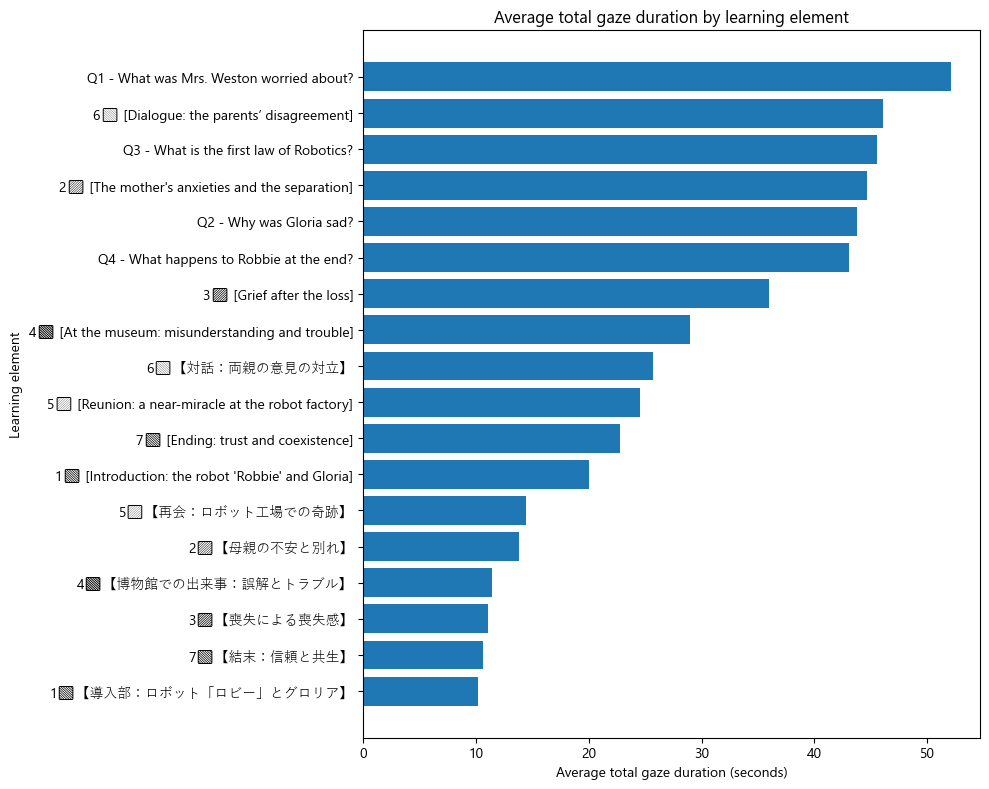

In [14]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Segoe UI Emoji", "Yu Gothic"]

plot_data = (
    avg_duration
    .sort_values("avg_gaze_duration", ascending=True)
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_data["aoi"],
    plot_data["avg_gaze_duration"]
)

plt.xlabel("Average total gaze duration (seconds)")
plt.ylabel("Learning element")
plt.title("Average total gaze duration by learning element")

plt.tight_layout()
plt.show()

In [15]:
plot_data

,aoi,elementType,avg_gaze_duration,avg_episode_duration,avg_episode_count
1,1🟦【導入部：ロボット「ロビー」とグロリア】,instruction,10.145771,0.609202,14.285714
13,7🟦【結末：信頼と共生】,instruction,10.666333,0.412657,20.030303
5,3🟩【喪失による喪失感】,instruction,11.033800,0.364350,26.742857
7,4🟥【博物館での出来事：誤解とトラブル】,instruction,11.402912,0.423855,27.323529
3,2🟧【母親の不安と別れ】,instruction,13.812514,0.433143,26.371429
9,5🟨【再会：ロボット工場での奇跡】,instruction,14.402457,0.532193,28.114286
0,1🟦 [Introduction: the robot 'Robbie' and Gloria],instruction,19.980657,0.759471,22.657143
12,7🟦 [Ending: trust and coexistence],instruction,22.743029,0.427414,33.676471
8,5🟨 [Reunion: a near-miracle at the robot factory],instruction,24.530000,0.523504,36.600000
11,6🟫【対話：両親の意見の対立】,instruction,25.674600,0.726584,28.228571


So, one inference is questions had more gaze than story elements, and japanese elements had apparently lesser gaze than english elements

Question elements exhibited higher average total gaze duration than story elements. Among the story elements, the English versions generally exhibited higher average total gaze duration than their corresponding Japanese versions. So did the learners engage with English element more or Japanese element more, need to account for episode count or switches also 

In [16]:
features = [
    "avg_gaze_duration",
    "avg_episode_duration",
    "avg_episode_count",
    "total_switches",
]

pearson_corr = element_analysis[features].corr(
    method="pearson"
)

spearman_corr = element_analysis[features].corr(
    method="spearman"
)

print("Pearson correlation:")
display(pearson_corr)

print("Spearman correlation:")
display(spearman_corr)

Pearson correlation:


,avg_gaze_duration,avg_episode_duration,avg_episode_count,total_switches
avg_gaze_duration,1.000000,0.712740,0.394200,0.608157
avg_episode_duration,0.712740,1.000000,-0.266272,-0.071025
avg_episode_count,0.394200,-0.266272,1.000000,0.939433
total_switches,0.608157,-0.071025,0.939433,1.000000


Spearman correlation:


,avg_gaze_duration,avg_episode_duration,avg_episode_count,total_switches
avg_gaze_duration,1.000000,0.772962,0.533540,0.659443
avg_episode_duration,0.772962,1.000000,-0.001032,0.135191
avg_episode_count,0.533540,-0.001032,1.000000,0.952528
total_switches,0.659443,0.135191,0.952528,1.000000


Across learners, do elements that receive more total gaze time also tend to have more switching?
<br>
more episodes → more switches → more total gaze duration.

Episode count received high correlation to switches as expected.

We use <br>
How much time? + How many separate gaze episodes?

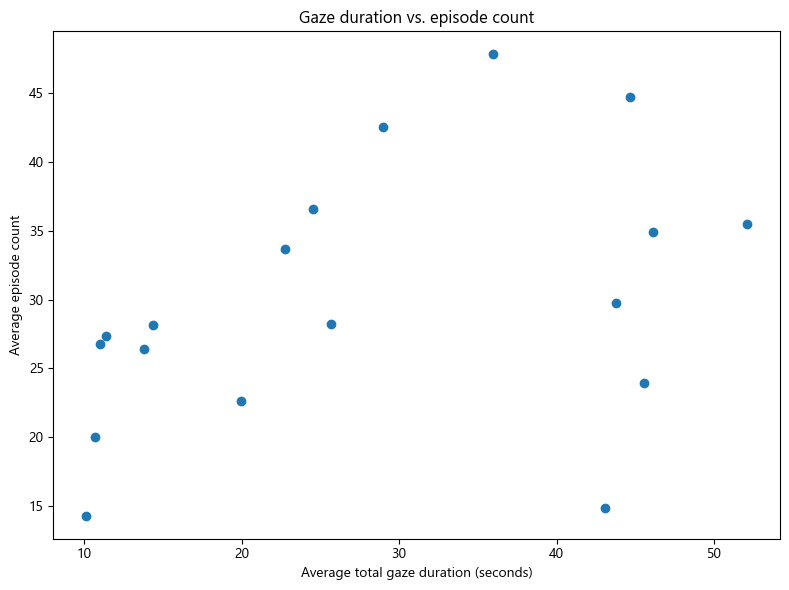

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    element_analysis["avg_gaze_duration"],
    element_analysis["avg_episode_count"]
)

plt.xlabel("Average total gaze duration (seconds)")
plt.ylabel("Average episode count")
plt.title("Gaze duration vs. episode count")

plt.tight_layout()
plt.show()

From  scatter plot, there appears to be scope for three gaze-behavior profiles based on:

Total gaze duration
Episode count

For example, we can potentially distinguish elements with:

Lower duration + lower/moderate episode count
Higher duration + higher episode count
Higher duration + lower episode count

So we can use K-means on avg_gaze_duration and avg_episode_count.

In [18]:
element_analysis_final = element_analysis.drop(
    columns=["avg_episode_duration", "total_switches"]
)

element_analysis_final

,aoi,avg_gaze_duration,avg_episode_count
0,1🟦 [Introduction: the robot 'Robbie' and Gloria],19.980657,22.657143
1,1🟦【導入部：ロボット「ロビー」とグロリア】,10.145771,14.285714
2,2🟧 [The mother's anxieties and the separation],44.639629,44.742857
3,2🟧【母親の不安と別れ】,13.812514,26.371429
4,3🟩 [Grief after the loss],35.957229,47.828571
5,3🟩【喪失による喪失感】,11.033800,26.742857
6,4🟥 [At the museum: misunderstanding and trouble],28.986000,42.514286
7,4🟥【博物館での出来事：誤解とトラブル】,11.402912,27.323529
8,5🟨 [Reunion: a near-miracle at the robot factory],24.530000,36.600000
9,5🟨【再会：ロボット工場での奇跡】,14.402457,28.114286


Preparing for
<br>
RQ2: How can learning elements be clustered based on the actual gaze behavior exhibited by the students?

We did not use clustering to rediscover language categories. We used it to determine whether semantic organisation corresponded to actual learner gaze behaviour.

So we can determine whether the designer's organisation of learning elements is reflected in learners' observed gaze behaviour.

Useful for: instructional designers, because it validates how learning elements were organised, and can reveal mismatches based on actual learner behaviour

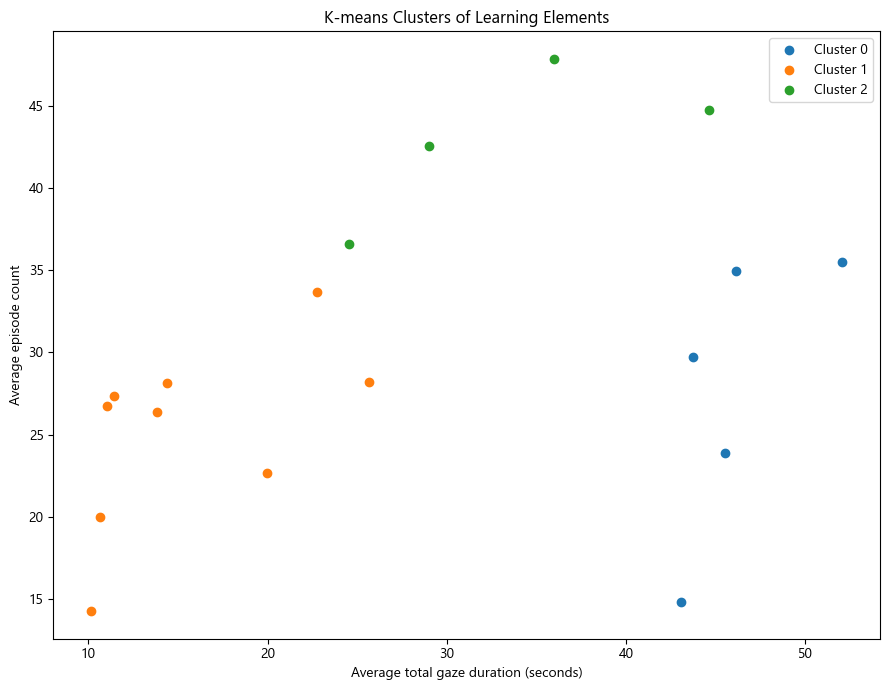

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = element_analysis[["avg_gaze_duration", "avg_episode_count"]]

X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
element_analysis["cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(9, 7))

for cluster in sorted(element_analysis["cluster"].unique()):
    data = element_analysis[element_analysis["cluster"] == cluster]
    plt.scatter(
        data["avg_gaze_duration"],
        data["avg_episode_count"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Average total gaze duration (seconds)")
plt.ylabel("Average episode count")
plt.title("K-means Clusters of Learning Elements")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
clustered_element_analysis = element_analysis[
    ["aoi", "avg_gaze_duration", "avg_episode_count", "cluster"]
].sort_values(["cluster", "avg_gaze_duration"])
clustered_element_analysis

,aoi,avg_gaze_duration,avg_episode_count,cluster
17,Q4 - What happens to Robbie at the end?,43.089882,14.852941,0
15,Q2 - Why was Gloria sad?,43.742235,29.735294,0
16,Q3 - What is the first law of Robotics?,45.536206,23.911765,0
10,6🟫 [Dialogue: the parents’ disagreement],46.112147,34.941176,0
14,Q1 - What was Mrs. Weston worried about?,52.076441,35.470588,0
1,1🟦【導入部：ロボット「ロビー」とグロリア】,10.145771,14.285714,1
13,7🟦【結末：信頼と共生】,10.666333,20.030303,1
5,3🟩【喪失による喪失感】,11.033800,26.742857,1
7,4🟥【博物館での出来事：誤解とトラブル】,11.402912,27.323529,1
3,2🟧【母親の不安と別れ】,13.812514,26.371429,1


| Cluster | Gaze profile | Elements | Interpretation |
|---|---|---|---|
| **Cluster 0** | **High duration + fewer episode count** | Q1–Q4 + English dialogue | Questions show **longer gaze duration** with fewer separate episodes, showing sustained engagement. |
| **Cluster 1** | **Low duration + fewer episode count** | Nearly all Japanese paragraphs + English paragraphs (1 Start and 7 Ending) | These elements receive **less gaze overall** and fewer episodes.|
| **Cluster 2** | **Moderate duration + high episode count** | Later English paragraphs (Sections 2–5) | These elements receive **more frequent gaze episodes**, suggesting repeated returns and potentially back-and-forth attention with other elements. |

The clustering was necessary because the English, Japanese, and question categories were known **a priori**, but their **gaze behaviour was not**. Data-driven clustering therefore independently identified behavioural groups, which could then be compared with the existing organisation of the learning material. In this case, the resulting clusters broadly matched the design of learning activity.

In [21]:
clustered_element_analysis.to_csv("clustered_element_analysis.csv", index=False)